In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import k_means
from fcmeans import FCM

import numpy as np
import plotly.io as pio
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

pio.renderers.default = 'vscode'

In [6]:
data = pd.read_csv("data/ethnic female.csv", sep=";")
data.head(5)

,национальность,рост,масса,ширина плеч,ширина таза
0,рус,"151,5","52,4",37,28
1,рус,171,48,34,27
2,рус,159,"76,6",39,39
3,рус,169,70,38,"31,5"
4,рус,172,61,"37,5","30,5"


In [7]:
print(data["национальность"].unique())

<StringArray>
['рус', 'хак', 'тув']
Length: 3, dtype: str


In [8]:
required_columns = ["рост", "масса", "ширина плеч", "ширина таза"]

for col in required_columns:
    data[col] = data[col].astype(str).str.replace(",", ".", regex=False)

data = data.dropna()

for col in required_columns:
    data[col] = data[col].astype(float)


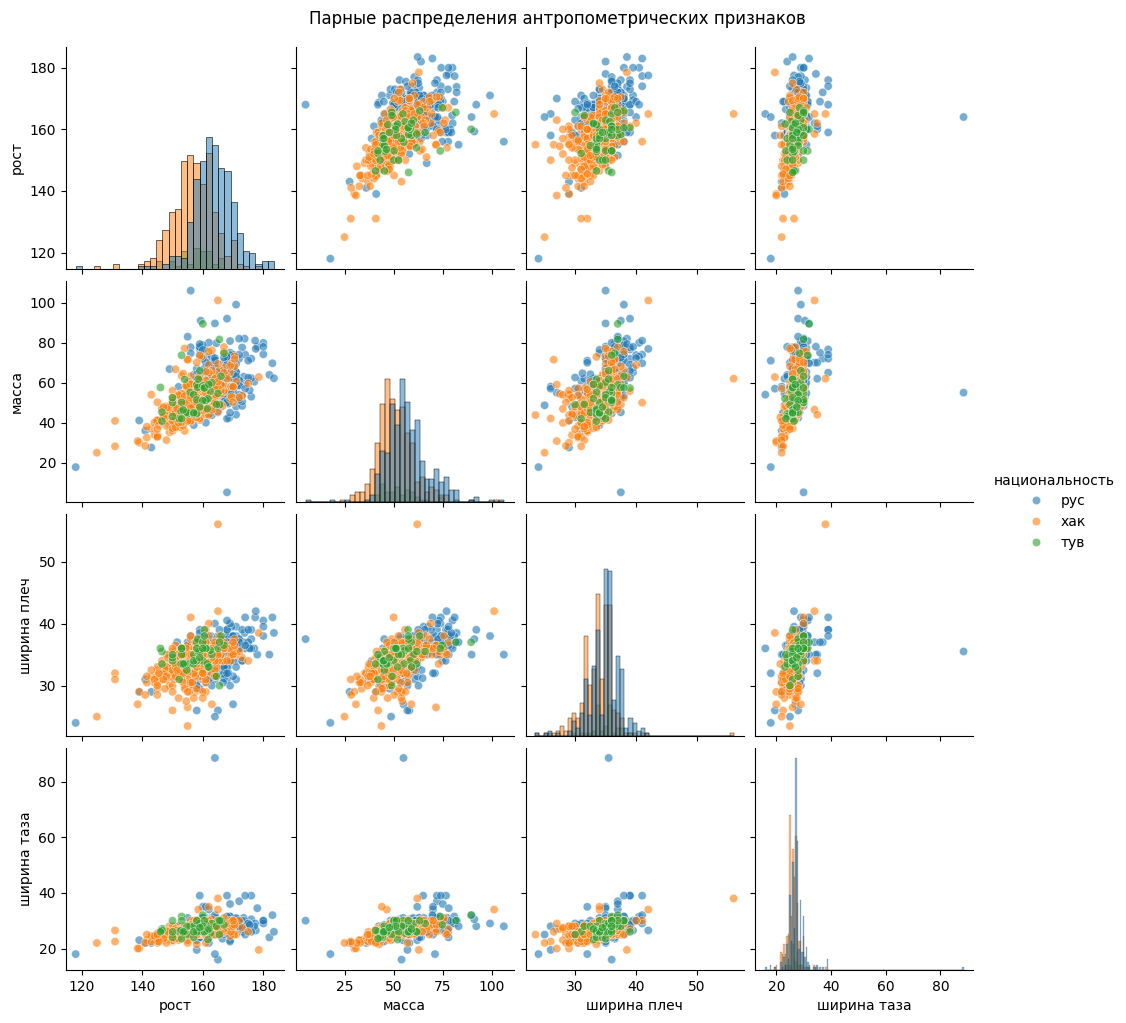

In [15]:
sns.pairplot(data, hue='национальность', 
             vars=['рост', 'масса', 'ширина плеч', 'ширина таза'],
             diag_kind='hist',  # на диагонали гистограммы
             plot_kws={'alpha': 0.6})
plt.suptitle('Парные распределения антропометрических признаков', y=1.02)
plt.show()

In [16]:
# Функция для удаления выбросов по IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        print(f"{col}: удалено {len(outliers)} выбросов")
        
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
    print(f"\nИсходный размер: {len(df)}")
    print(f"Размер после удаления: {len(df_clean)}")
    print(f"Удалено всего: {len(df) - len(df_clean)} строк")
    return df_clean

# Применяем к числовым признакам
numeric_cols = ['рост', 'масса', 'ширина плеч', 'ширина таза']
data = remove_outliers_iqr(data, numeric_cols)

рост: удалено 15 выбросов
масса: удалено 31 выбросов
ширина плеч: удалено 15 выбросов
ширина таза: удалено 14 выбросов

Исходный размер: 740
Размер после удаления: 665
Удалено всего: 75 строк


In [17]:
X = data[['рост', 'масса', 'ширина плеч', 'ширина таза']].values
y = data['национальность'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия для 3 компонент: {sum(pca.explained_variance_ratio_):.3f}")

Объясненная дисперсия: [0.64130479 0.14240404 0.12464518]
Суммарная объясненная дисперсия для 3 компонент: 0.908


In [18]:
# Создаем DataFrame для Plotly
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'национальность': y
})

# 3D scatter plot
fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    color='национальность',
                    title='3D PCA проекция антропометрических данных',
                    labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
                            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
                            'PC3': f'PC3 ({pca.explained_variance_ratio_[2]:.1%})'},
                    opacity=0.7)

fig.update_layout(width=800, height=600)
fig.show()

In [23]:
X_pca_2d = X_pca[:, :2]

gmm = GaussianMixture(n_components=3, random_state=42)
cluster_labels = gmm.fit_predict(X_pca_2d)

pca_df['кластер'] = cluster_labels

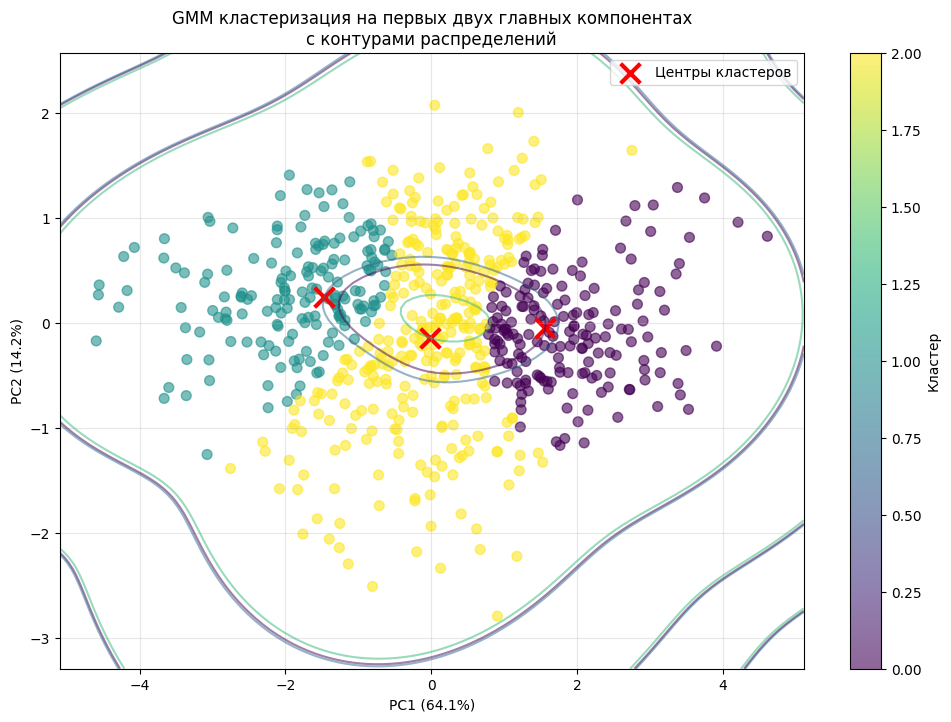

In [25]:
x_min, x_max = X_pca_2d[:, 0].min() - 0.5, X_pca_2d[:, 0].max() + 0.5
y_min, y_max = X_pca_2d[:, 1].min() - 0.5, X_pca_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))


Z = -gmm.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=cluster_labels, cmap='viridis', 
                      alpha=0.6, s=50)

# Добавляем контуры распределений для каждой компоненты
for i in range(3):
    Z_comp = -gmm.score_samples(np.c_[xx.ravel(), yy.ravel()]) + gmm.score_samples(np.c_[gmm.means_[i].reshape(1, -1)])
    Z_comp = Z_comp.reshape(xx.shape)
    plt.contour(xx, yy, Z_comp, levels=3, alpha=0.5, 
                colors=[plt.cm.viridis(i/3)])

plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], 
            c='red', marker='x', s=200, linewidths=3, 
            label='Центры кластеров')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('GMM кластеризация на первых двух главных компонентах\nс контурами распределений')
plt.colorbar(scatter, label='Кластер')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Распределение национальностей по кластерам:
col_0  рус  тув  хак
row_0               
0      112    9   51
1       34   13  126
2      157   20  143


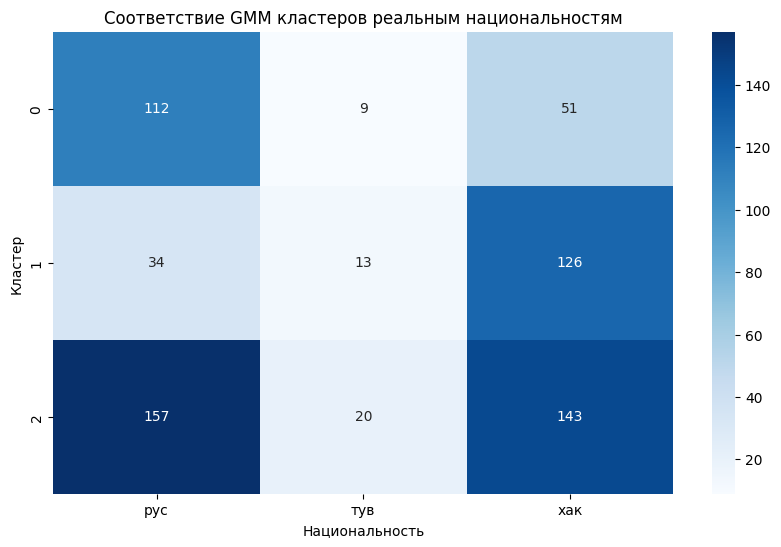

In [ ]:
cluster_nation = pd.crosstab(cluster_labels, y)
print("Распределение национальностей по кластерам:")
print(cluster_nation)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_nation, annot=True, fmt='d', cmap='Blues')
plt.title('Соответствие GMM кластеров реальным национальностям')
plt.xlabel('Национальность')
plt.ylabel('Кластер')
plt.show()